# Mobility data characterization

This notebook is part of the broader memorization analysis framework for mobility sequence predictors. The goal of this notebook is to characterize the mobility behavior of users in the training datasets of all memorization types.

In [ ]:
from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta
import sys
sys.path.append('./Helpers/')
from diversity import diversity
from mobilityProfiling import mobilityProfiling
from maxPredictability import entropy_kontoyiannis, max_predictability
from master_thesis.preprocessing.utils import save_dict, load_dict
from rg_computation import rg_unique, rg_event, rg_time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic
import pickle
import os
#import skmob
import string
import math
import uuid
import random
import argparse
from collections import defaultdict
import unicodedata
from functools import reduce
#from skmob.measures.individual import radius_of_gyration, home_location
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings("ignore")


In [11]:
DATASET_NAME_TO_FOLDER_NAME = {
    'shenzhenurban': 'ShenzhenUrban',
    'shanghaikaggle': 'ShanghaiKaggle',
    'yjmob100k': 'YJMob100Kv3'
}
dataset_name = "yjmob100k"


norm1_training_path = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType1' 
)

norm2_training_home_path = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType2' / 'Home' 
)

norm2_training_work_path = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType2' / 'Work' 
)

norm3_training_path = (
    Path('PreprocessedData/2SplittedData') /
    DATASET_NAME_TO_FOLDER_NAME[dataset_name] /
    'NormalizationType3'
)

In [12]:
def haversine_distance(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a)) 
    r = 6371  # Radius of earth in kilometers
    
    # Calculate the distance
    distance = c * r
    
    return distance

def rcm_unique(df):
    N = df.N.unique()[0]
    x_cm = df.x.sum()/N
    y_cm = df.y.sum()/N
    
    return (x_cm, y_cm)

def rcm_time(df):
    sk_total = df.sk_total.unique()[0]
    x_cm = (df.x*df.sk).sum()/sk_total
    y_cm = (df.y*df.sk).sum()/sk_total
    
    return (x_cm, y_cm)

def LatLonToMeters(lat, lon):
    "Converts given lat/lon in WGS84 Datum to XY in Spherical Mercator EPSG:900913"
    originShift = 2 * math.pi * 6378137 / 2.0
    mx = lon * originShift / 180.0
    my = math.log( math.tan((90 + lat) * math.pi / 360.0 )) / (math.pi / 180.0)

    my = my * originShift / 180.0
    return mx, my

    
def calculate_distance_squared(point1, point2):
    x1, y1 = point1
    x2, y2 = point2
    distance_squared = (x2 - x1) ** 2 + (y2 - y1) ** 2
    return distance_squared

def map_to_char(df, N=1000):
    df = df[df.cid.diff().fillna(1) != 0]
    identifiants = df.cid
    user_id = df['id'].unique()[0]
    all_chars = [chr(code_point) for code_point in range(0, N+1)]

    if identifiants.nunique() <= len(all_chars):
        char_map = {} 
        i=0
        for identifiant in identifiants:
            if identifiant not in char_map:
                char_map[identifiant] = all_chars[i] 
                i=i+1
        mapped_string = ''.join(char_map[identifiant] for identifiant in identifiants)
        return mapped_string
    else:
        return "error"
    
def get_mobility_metrics(df):
    #Radius of gyration: 
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna()
    df.rename(columns={'tid':'id'}, inplace=True)
    
    print("- Radius of gyration")
    ## Radius of gyration unique
    df_rg1 = rg_unique(df.rename(columns={'lat':'latitude', 'lon':'longitude'}))
    # df_rg2 = rg_event(df.rename(columns={'lat':'latitude', 'lon':'longitude'}))
    # rgs_df = pd.merge(left=df_rg1, right=df_rg2, on='id', how='inner')[['id', 'rg_unique', 'rg_event']]
    rgs_df = df_rg1
    
    #Repetitiveness and n_unique
    print("- Repetitiveness, N_unique")
    df['cid'] = df.groupby(['lat', 'lon'], sort=False).ngroup()
    rep_df = pd.merge(left = df.groupby('id').cid.nunique().reset_index(name='n_unique'),
         right = df.groupby('id').size().reset_index(name='n'),
         on='id',
         how='inner')
    rep_df['repetitiveness'] = 1 - (rep_df['n_unique']/rep_df['n'])
    
    #Stationarity:
    print("- Stationarity")
    df['sta'] = (df.groupby('id').cid.diff().fillna(1) == 0)
    sta_df = pd.merge(left = df.groupby('id').sta.sum().reset_index(name='strans'),
         right = df.groupby('id').size().reset_index(name='n'),
         on='id',
         how='left')

    sta_df['stationarity']  = sta_df['strans']/(sta_df['n']-1)
    # #Speed
    # print("- Speed")
    # df_sorted = df.sort_values(by=['id', 'timestamp'])
    # df_sorted['iet'] = df_sorted.groupby('id').timestamp.diff().dt.total_seconds()/60
    # df1 = df_sorted[['lat', 'lon']].rename(columns={'lat':'lat1', 'lon':'lon1'})
    # df2 = df_sorted[['lat', 'lon']].rename(columns={'lat':'lat2', 'lon':'lon2'}).shift()
    # merged_df = pd.merge(left=df1, right=df2, left_index=True, right_index=True)
    # merged_df['distance'] = merged_df.apply(lambda x: haversine_distance(x['lat1'], x['lon1'], x['lat2'], x['lon2']), axis=1)
    # df_sorted = df_sorted.merge(right=merged_df[["distance"]], left_index=True, right_index=True)
    # df_sorted =df_sorted[df_sorted['iet']<=30]
    # df_sorted['speed'] = df_sorted['distance']/(df_sorted['iet']/60)
    # speed_df = df_sorted[['id', 'timestamp', 'speed']]
    
    #diversity
    print("- Diversity")
    N_value = df.groupby('id').cid.nunique().max() 
    div_df = df.groupby('id').apply(map_to_char, N=N_value).reset_index(name="string")
    div_df['diversity'] = div_df.string.apply(diversity)
    
    #mobility profiles
    print("- Mobility profiles")
    listUsr = df.id.unique()
    df_exp_ret = df.rename(columns={"id":'usr', 'timestamp':'date', 'cid':'geohash'})[['usr','date','geohash']]
    df_exp_ret.geohash = df_exp_ret.geohash.astype('str')
    df_exp_ret = df_exp_ret.set_index('usr')
    mobilityProfiling(df_exp_ret, listUsr)
    regulars = pd.read_csv("regulars.csv", sep='#')
    scouters = pd.read_csv("scouters.csv", sep='#')
    routiners = pd.read_csv("routiners.csv", sep='#')
    os.remove("regulars.csv")
    os.remove("scouters.csv")
    os.remove("routiners.csv")
    regulars_ids = regulars['regulars (dev_id)'].str.split(',').iloc[0]
    routiners_ids = routiners['routiners (dev_id)'].str.split(',').iloc[0]
    scouters_ids = scouters['scouters (dev_id)'].str.split(',').iloc[0]
    
    profile_df = {'id':[], 'profile':[]}
    for val in regulars_ids:
        profile_df['id'].append(val)
        profile_df['profile'].append("regular")
    for val in routiners_ids:
        profile_df['id'].append(val)
        profile_df['profile'].append("routiner")
    for val in scouters_ids:
        profile_df['id'].append(val)
        profile_df['profile'].append("scouter")
    profile_df = pd.DataFrame(profile_df)
    #profile_df.id = profile_df.id.astype(int)

    #exploration and returns
    # print("- Exploration and returns")
    # expl_df = df.groupby(['id', 'cid']).size().reset_index(name="freq")
    # expl_df = expl_df.merge(right=df.groupby('id').cid.size().reset_index(name="tot_freq"),
    #           on='id',
    #           how='left')
    # expl_df["norm_freq"] = expl_df["freq"]/expl_df["tot_freq"]
    # expl_df = expl_df.merge(right=expl_df.groupby('id').norm_freq.max().reset_index(name="max_freq"),
    #           on='id',
    #           how='left')
    # known_loc_df = expl_df[expl_df['norm_freq'] >= 0.9*expl_df['max_freq']]
    # known_locs = known_loc_df.groupby('id').cid.unique().apply(lambda x: x.tolist()).to_dict()
    # def parcours(user_id, cid):
    #     #print(known_locs[user_id])
    #     if cid in known_locs[user_id]:
    #         return "Ret"
    #     else:
    #         known_locs[user_id].append(cid)
    #         return "Exp"
    
    # df['visit_type'] = df.apply(lambda x: parcours(x['id'],x['cid']), axis=1)
    
    #predictability
    print("- Predictability")
    N_value = df.groupby('id').cid.nunique().max() 
    n_df = df.groupby('id').cid.nunique().reset_index(name="size")
    pre_df = df.groupby('id').apply(map_to_char, N=N_value).reset_index(name="string")
    pre_df['ent_kont'] = pre_df.string.apply(entropy_kontoyiannis)
    pre_df = pre_df.merge(right=n_df, on='id')
    pre_df['predictability'] = pre_df.apply(lambda x: max_predictability(x['ent_kont'], x['size']), axis=1)
    
    dfs = [rgs_df, rep_df, sta_df, div_df, profile_df, pre_df]
    for d in dfs:
        d['id'] = d['id'].astype(str)
    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on='id', how='inner')
    
    merged = merged.rename(columns={'id': 'tid'})

    return merged
    # return {'rg':rgs_df,
    #         'repetitiveness':rep_df,
    #         'stationarity':sta_df, 
    #         'diversity':div_df, 
    #        'profile':profile_df, 
    #        'predictability':pre_df}

In [56]:
for norm_data_path in [norm1_training_path, norm2_training_home_path, norm2_training_work_path, norm3_training_path]:
#for norm_data_path in [norm3_training_path]:
    if not os.path.exists(norm_data_path):
        print(norm_data_path, "does not exist")
    else:
        print("Processing", norm_data_path)
    training_df = pd.read_csv(norm_data_path / 'Datasets'/ 'training_set.csv')
    mobility_df = get_mobility_metrics(training_df)
    norm_data_path.mkdir(parents=True, exist_ok=True)  # Ensure directory exists
    mobility_df.to_csv(norm_data_path / 'mobility_characteristics.csv', index=False)

Processing PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType1
- Radius of gyration
- Repetitiveness, N_unique
- Stationarity
- Diversity
- Mobility profiles
- Predictability
Processing PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType2/Home
- Radius of gyration
- Repetitiveness, N_unique
- Stationarity
- Diversity
- Mobility profiles
- Predictability
Processing PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType2/Work
- Radius of gyration
- Repetitiveness, N_unique
- Stationarity
- Diversity
- Mobility profiles
- Predictability
Processing PreprocessedData/2SplittedData/YJMob100Kv3/NormalizationType3
- Radius of gyration
- Repetitiveness, N_unique
- Stationarity
- Diversity
- Mobility profiles
- Predictability


In [13]:
# Normalization paths

# -----------------------------
# Helper: collect reference set sizes
# -----------------------------
def collect_refset_sizes_for_norm(norm_path_or_list):
    """
    norm_path_or_list: Path or list[Path]
    Returns: list of reference set sizes (one per training trajectory).
    """
    sizes = []

    # Allow passing either a single Path or a list of Paths (for Type2 home+work)
    if isinstance(norm_path_or_list, (list, tuple)):
        paths = norm_path_or_list
    else:
        paths = [norm_path_or_list]

    for path in paths:
        datasets_dir = path / 'Datasets'
        if not datasets_dir.exists():
            continue

        for csv_file in datasets_dir.glob("*.csv"):
            if csv_file.name == "training_set.csv":
                continue  # skip the global training set

            df = pd.read_csv(csv_file)
            # One reference trajectory per unique tid
            n_ref = df["tid"].nunique()
            sizes.append(n_ref)

    return sizes

# Which datasets (and order) to plot
datasets_order = ['shenzhenurban', 'shanghaikaggle', 'yjmob100k']

# For nicer titles
dataset_label = {
    'shenzhenurban': 'ShenzhenUrb',
    'shanghaikaggle': 'ShanghaiTel',
    'yjmob100k': 'YJMob100K'
}

# Display names for normalization types
norm_display = {
    "Location": "Location",
    "Anchor-home": "Anchor (home)",
    "Anchor-work": "Anchor (work)",
}

# -----------------------------
# Collect reference-set sizes
# -----------------------------
norm_to_sizes = {}

for dataset_name, folder_name in DATASET_NAME_TO_FOLDER_NAME.items():
    base_dir = Path('PreprocessedData/2SplittedData') / folder_name

    norm_paths = {
        "Location":     base_dir / 'NormalizationType1',
        "Anchor-home":  base_dir / 'NormalizationType2' / 'Home',
        "Anchor-work":  base_dir / 'NormalizationType2' / 'Work',
    }

    norm_to_sizes[dataset_name] = {}

    for norm_label, norm_path in norm_paths.items():
        sizes = collect_refset_sizes_for_norm(norm_path)
        # Filter out zero or missing just in case
        sizes = [s for s in sizes if s > 0]
        norm_to_sizes[dataset_name][norm_label] = sizes

        print(
            f"{dataset_name} - {norm_label}: "
            f"{len(sizes)} training trajectories, "
            f"min={min(sizes) if sizes else 'NA'}, "
            f"max={max(sizes) if sizes else 'NA'}"
        )

shenzhenurban - Location: 2000 training trajectories, min=100, max=144891
shenzhenurban - Anchor-home: 2000 training trajectories, min=100, max=86991
shenzhenurban - Anchor-work: 2000 training trajectories, min=100, max=86991
shanghaikaggle - Location: 2000 training trajectories, min=100, max=13277
shanghaikaggle - Anchor-home: 2000 training trajectories, min=100, max=6051
shanghaikaggle - Anchor-work: 2000 training trajectories, min=100, max=5922
yjmob100k - Location: 2000 training trajectories, min=100, max=64794
yjmob100k - Anchor-home: 2000 training trajectories, min=100, max=901
yjmob100k - Anchor-work: 2000 training trajectories, min=100, max=1106


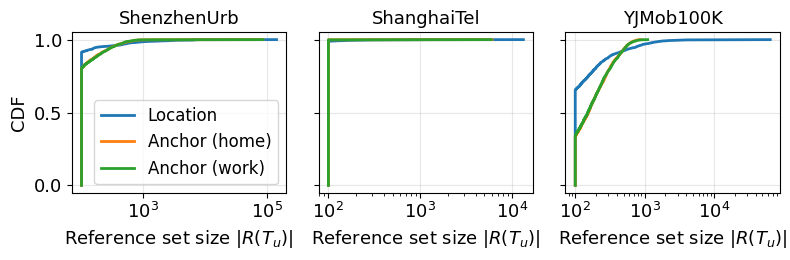

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

#for ax, ds_name in zip(axes, datasets_order):
for i, (ds_name, norm_map) in enumerate(norm_to_sizes.items()):
    ax = axes[i]
    norms_dict = norm_to_sizes.get(ds_name, {})
    for norm_label in ["Location", "Anchor-home", "Anchor-work"]:
        sizes = norms_dict.get(norm_label, [])
        if not sizes:
            continue
        arr = np.sort(np.array(sizes))
        cdf = np.arange(1, len(arr) + 1) / len(arr)
        ax.plot(arr, cdf, label=norm_display[norm_label], linewidth=2)

    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_title(dataset_label[ds_name], fontsize=13)
    ax.tick_params(axis='both', labelsize=13)
     # legend only on FIRST subplot
    if i == 0:
        ax.legend(fontsize=12)

# Axis labels
axes[0].set_ylabel("CDF", fontsize=13)
for ax in axes:
    ax.set_xlabel(r"Reference set size $|R(T_u)|$", fontsize=13)
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=13)



plt.tight_layout(rect=[0, 0.1, 1, 1])  # leave space at bottom for legend

# Save
OUTPUT_DIR = Path("analysis_outputs") / "refset_sizes"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "cdf_refset_sizes.pdf", dpi=300)
#plt.close()

In [ ]:
def compute_cluster_spread_stats_from_sets_location(training_set, reference_sets, max_refs=10000):
    """
    Computes avg and var for both:
    - geodesic distances between training origin and reference origins
    - Euclidean distances between training pattern and reference patterns
    Args:
        training_set: list of trajectory dicts (with 'traj_id', 'origin', 'pattern')
        reference_sets: dict {train_tid → list of reference trajectory dicts}
        max_refs: max number of reference trajs to consider (for huge clusters)

    Returns:
        DataFrame with per-cluster stats
    """
    stats = []

    for train_traj in training_set:
        tid = train_traj['traj_id']
        train_pattern = np.array(train_traj['pattern']).flatten()
        train_origin = train_traj.get('origin')
        refs = reference_sets.get(tid, [])

        if not train_origin or not train_pattern.any() or len(refs) < 2:
            continue

        # Sample if needed
        if len(refs) > max_refs:
            refs = np.random.choice(refs, size=max_refs, replace=False)

        ref_patterns = [np.array(r['pattern']).flatten() for r in refs if r.get('pattern') is not None]
        ref_origins = [r.get('origin') for r in refs if r.get('origin') is not None]

        if len(ref_patterns) < 2 or len(ref_origins) < 2:
            continue

        ref_patterns = np.stack(ref_patterns)

        # Pattern distances
        pattern_dists = np.linalg.norm(ref_patterns - train_pattern, axis=1)
        avg_pattern_dist = np.mean(pattern_dists)
        var_pattern_dist = np.var(pattern_dists)

        # Geo distances
        geo_dists = [geodesic(train_origin, o).km for o in ref_origins]
        avg_geo_dist = np.mean(geo_dists)
        var_geo_dist = np.var(geo_dists)

        stats.append({
            'train_tid': tid,
            'num_refs': len(refs),
            'avg_geo_dist_km': avg_geo_dist,
            'var_geo_dist_km': var_geo_dist,
            'avg_pattern_dist': avg_pattern_dist,
            'var_pattern_dist': var_pattern_dist
        })

    return pd.DataFrame(stats)

def compute_cluster_spread_stats_from_sets_pair(training_set, reference_sets, max_refs=10000, current_selection='work'):
    """
    Computes avg and var for both:
    - geodesic distances between training origin and reference origins
    - Euclidean distances between training pattern and reference patterns
    Args:
        training_set: list of trajectory dicts (with 'traj_id', 'home'/'work', 'pattern')
        reference_sets: dict {train_tid → list of reference trajectory dicts}
        max_refs: max number of reference trajs to consider (for huge clusters)

    Returns:
        DataFrame with per-cluster stats
    """
    stats = []

    for train_traj in training_set:
        tid = train_traj['traj_id']
        train_pattern = np.array(train_traj['pattern']).flatten()
        train_origin = train_traj.get(current_selection)  # 'home' or 'work'
        refs = reference_sets.get(tid, [])

        if not train_origin or not train_pattern.any() or len(refs) < 2:
            continue

        # Sample if needed
        if len(refs) > max_refs:
            refs = np.random.choice(refs, size=max_refs, replace=False)

        ref_patterns = [np.array(r['pattern']).flatten() for r in refs if r.get('pattern') is not None]
        ref_origins = [r.get(current_selection) for r in refs if r.get(current_selection) is not None]

        if len(ref_patterns) < 2 or len(ref_origins) < 2:
            continue

        ref_patterns = np.stack(ref_patterns)

        # Pattern distances
        pattern_dists = np.linalg.norm(ref_patterns - train_pattern, axis=1)
        avg_pattern_dist = np.mean(pattern_dists)
        var_pattern_dist = np.var(pattern_dists)

        # Geo distances
        geo_dists = [geodesic(train_origin, o).km for o in ref_origins]
        avg_geo_dist = np.mean(geo_dists)
        var_geo_dist = np.var(geo_dists)

        stats.append({
            'train_tid': tid,
            'num_refs': len(refs),
            'avg_geo_dist_km': avg_geo_dist,
            'var_geo_dist_km': var_geo_dist,
            'avg_pattern_dist': avg_pattern_dist,
            'var_pattern_dist': var_pattern_dist
        })

    return pd.DataFrame(stats)

def compute_cluster_spread_stats_from_sets_location_yjmob(training_set, reference_sets, max_refs=10000, cell_km=0.5):
    """
    YJMob version (grid-based coordinates).
    Computes avg and var for:
    - spatial distances between training origin and reference origins (in km, via grid * cell_km)
    - Euclidean distances between training pattern and reference patterns

    Args:
        training_set: list of trajectory dicts (with 'traj_id', 'origin', 'pattern')
        reference_sets: dict {train_tid → list of reference trajectory dicts}
        max_refs: max number of reference trajs to consider (for huge clusters)
        cell_km: size of one grid step in kilometers (default: 0.5 km for 500m cells)

    Returns:
        DataFrame with per-cluster stats
    """
    stats = []

    for train_traj in training_set:
        tid = train_traj['traj_id']
        train_pattern = np.array(train_traj['pattern']).flatten()
        train_origin = train_traj.get('origin')  # expected (x, y)
        refs = reference_sets.get(tid, [])

        if train_origin is None or not train_pattern.any() or len(refs) < 2:
            continue

        # Sample if needed
        if len(refs) > max_refs:
            refs = np.random.choice(refs, size=max_refs, replace=False)

        ref_patterns = [np.array(r['pattern']).flatten() for r in refs if r.get('pattern') is not None]
        ref_origins = [r.get('origin') for r in refs if r.get('origin') is not None]

        if len(ref_patterns) < 2 or len(ref_origins) < 2:
            continue

        ref_patterns = np.stack(ref_patterns)

        # Pattern distances
        pattern_dists = np.linalg.norm(ref_patterns - train_pattern, axis=1)
        avg_pattern_dist = np.mean(pattern_dists)
        var_pattern_dist = np.var(pattern_dists)

        # Grid-based spatial distances (convert to km)
        train_origin_arr = np.array(train_origin, dtype=float)
        geo_dists = []
        for o in ref_origins:
            o_arr = np.array(o, dtype=float)
            grid_dist = np.linalg.norm(o_arr - train_origin_arr)
            geo_dists.append(grid_dist * cell_km)

        avg_geo_dist = np.mean(geo_dists)
        var_geo_dist = np.var(geo_dists)

        stats.append({
            'train_tid': tid,
            'num_refs': len(refs),
            'avg_geo_dist_km': avg_geo_dist,
            'var_geo_dist_km': var_geo_dist,
            'avg_pattern_dist': avg_pattern_dist,
            'var_pattern_dist': var_pattern_dist
        })

    return pd.DataFrame(stats)


def compute_cluster_spread_stats_from_sets_pair_yjmob(training_set, reference_sets, max_refs=10000, current_selection='work', cell_km=0.5):
    """
    YJMob version for anchor pairs (home/work in grid coordinates).
    Computes avg and var for:
    - spatial distances between training anchor and reference anchors (in km, via grid * cell_km)
    - Euclidean distances between training pattern and reference patterns

    Args:
        training_set: list of trajectory dicts (with 'traj_id', 'home'/'work', 'pattern')
        reference_sets: dict {train_tid → list of reference trajectory dicts}
        max_refs: max number of reference trajs to consider (for huge clusters)
        current_selection: 'home' or 'work' (which anchor to use)
        cell_km: size of one grid step in kilometers (default: 0.5 km)

    Returns:
        DataFrame with per-cluster stats
    """
    stats = []

    for train_traj in training_set:
        tid = train_traj['traj_id']
        train_pattern = np.array(train_traj['pattern']).flatten()
        train_origin = train_traj.get(current_selection)  # (x, y) grid
        refs = reference_sets.get(tid, [])

        if train_origin is None or not train_pattern.any() or len(refs) < 2:
            continue

        # Sample if needed
        if len(refs) > max_refs:
            refs = np.random.choice(refs, size=max_refs, replace=False)

        ref_patterns = [np.array(r['pattern']).flatten() for r in refs if r.get('pattern') is not None]
        ref_origins = [r.get(current_selection) for r in refs if r.get(current_selection) is not None]

        if len(ref_patterns) < 2 or len(ref_origins) < 2:
            continue

        ref_patterns = np.stack(ref_patterns)

        # Pattern distances
        pattern_dists = np.linalg.norm(ref_patterns - train_pattern, axis=1)
        avg_pattern_dist = np.mean(pattern_dists)
        var_pattern_dist = np.var(pattern_dists)

        # Grid-based spatial distances (convert to km)
        train_origin_arr = np.array(train_origin, dtype=float)
        geo_dists = []
        for o in ref_origins:
            o_arr = np.array(o, dtype=float)
            grid_dist = np.linalg.norm(o_arr - train_origin_arr)
            geo_dists.append(grid_dist * cell_km)

        avg_geo_dist = np.mean(geo_dists)
        var_geo_dist = np.var(geo_dists)

        stats.append({
            'train_tid': tid,
            'num_refs': len(refs),
            'avg_geo_dist_km': avg_geo_dist,
            'var_geo_dist_km': var_geo_dist,
            'avg_pattern_dist': avg_pattern_dist,
            'var_pattern_dist': var_pattern_dist
        })

    return pd.DataFrame(stats)

datasets_order = ['shenzhenurban', 'shanghaikaggle', 'yjmob100k']

dataset_label = {
    'shenzhenurban': 'ShenzhenUrb',
    'shanghaikaggle': 'ShanghaiTel',
    'yjmob100k': 'YJMob100K'
}

norm_display = {
    "Location": "Location",
    "Anchor-home": "Anchor (home)",
    "Anchor-work": "Anchor (work)",
}

# -----------------------------
# Collect avg_geo_dist_km stats
# -----------------------------
geo_dist_stats = {}  # {dataset: {norm_label: [avg_geo_dist_km,...]}}

for dataset_name, folder_name in DATASET_NAME_TO_FOLDER_NAME.items():
    base_dir = Path('PreprocessedData/2SplittedData') / folder_name

    norm_paths = {
        "Location":     base_dir / 'NormalizationType1',
        "Anchor-home":  base_dir / 'NormalizationType2' / 'Home',
        "Anchor-work":  base_dir / 'NormalizationType2' / 'Work',
    }

    geo_dist_stats[dataset_name] = {}

    for norm_label, save_path_base in norm_paths.items():
        training_pkl = save_path_base / "training_set.pkl"
        refsets_pkl = save_path_base / "reference_sets.pkl"

        if not training_pkl.exists() or not refsets_pkl.exists():
            print(f"[WARN] Missing pickle files for {dataset_name} - {norm_label}, skipping.")
            continue

        training_set = load_dict(training_pkl)
        reference_sets = load_dict(refsets_pkl)
        if norm_label in ["Anchor-home", "Anchor-work"]:
            current_selection = 'home' if norm_label == "Anchor-home" else 'work'
            if dataset_name == "yjmob100k":
                cluster_stats_df = compute_cluster_spread_stats_from_sets_pair_yjmob(training_set, reference_sets, current_selection=current_selection)
            else:
                cluster_stats_df = compute_cluster_spread_stats_from_sets_pair(training_set, reference_sets, current_selection=current_selection)
        else:
            if dataset_name == "yjmob100k":
                cluster_stats_df = compute_cluster_spread_stats_from_sets_location_yjmob(training_set, reference_sets)
            else:
                cluster_stats_df = compute_cluster_spread_stats_from_sets_location(training_set, reference_sets)

        if cluster_stats_df.empty:
            print(f"[WARN] Empty stats for {dataset_name} - {norm_label}, skipping.")
            continue

        avg_geo = cluster_stats_df["avg_geo_dist_km"].dropna().values
        geo_dist_stats[dataset_name][norm_label] = avg_geo

        print(f"{dataset_name} - {norm_label}: {len(avg_geo)} clusters, "
              f"mean={np.mean(avg_geo):.2f} km, median={np.median(avg_geo):.2f} km")

In [ ]:
# -----------------------------
# Plot CDF of avg_geo_dist_km
# One row, 3 subplots (one per dataset)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)

for ax, ds_name in zip(axes, datasets_order):
    norms_dict = geo_dist_stats.get(ds_name, {})
    for norm_label in ["Location", "Anchor-home", "Anchor-work"]:
        vals = norms_dict.get(norm_label, None)
        if vals is None or len(vals) == 0:
            continue

        arr = np.sort(vals)
        cdf = np.arange(1, len(arr) + 1) / len(arr)
        ax.plot(arr, cdf, label=norm_display[norm_label], linewidth=2)

    ax.set_title(dataset_label[ds_name], fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=13)

# Axis labels
axes[0].set_ylabel("CDF", fontsize=13)
for ax in axes:
    ax.set_xlabel(r"Avg. geo distance (km)", fontsize=11)

# Legend only on first subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, fontsize=9, loc="lower right")

plt.tight_layout()

OUTPUT_DIR = Path("analysis_outputs") / "cluster_spread"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "cdf_avg_geo_dist_by_dataset_and_norm.pdf", dpi=300)
plt.close()